<a href="https://colab.research.google.com/github/gabrielsanchez/sussex-thesis/blob/main/dataset_visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Visualisation

### What the dataset contains

Each `.npz` file stores one configuration (distance $d$, rounds $r$,
noise parameters). Three arrays live inside:

| Array | Shape | Dtype | Meaning |
|-------|-------|-------|---------|
| `detector_events` | (shots, detectors) | uint8 | Did each parity-check fire? 1=yes, 0=no |
| `observable_flips` | (shots, observables) | uint8 | Did the logical qubit flip? 1=yes (error), 0=no |
| `erasure_heralds` | (shots, rounds, gates/round, 2) | bool | Was either qubit in a 2q gate lost (atom loss)? |

A companion `.json` stores metadata: distance, rounds, error rates,
timing, etc.

The decoder's job: given `detector_events` (and optionally
`erasure_heralds`), predict `observable_flips`.

In [ ]:
!pip install stim pymatching

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 14.5 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
from dataclasses import dataclass, asdict
import json
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import stim

plt.rcParams.update({
    "font.size": 12,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = Path("data")

## 0. Generate a demo dataset

If the full training files aren't present, generate a small one
($d=5$, 10 000 shots) on the fly so this notebook is self-contained.

In [ ]:
# --- Noise model (copied verbatim from the generation notebook) ---

@dataclass
class NeutralAtomNoise:
    p_depol1: float = 1e-3
    p_depol2: float = 5e-3
    p_meas: float = 5e-3
    p_reset: float = 1e-3
    p_correlated_zz: float = 1e-3
    p_erasure: float = 2e-3
    erasure_depol_strength: float = 0.75


def _emit(inst, out, n):
    name = inst.name
    targets = inst.targets_copy()
    if name in ("M", "MX", "MY", "MZ"):
        qbits = [t.value for t in targets if t.is_qubit_target]
        if qbits and n.p_meas > 0:
            out.append("X_ERROR", qbits, n.p_meas)
        out.append(inst)
        return
    if name == "MR":
        qbits = [t.value for t in targets if t.is_qubit_target]
        if qbits and n.p_meas > 0:
            out.append("X_ERROR", qbits, n.p_meas)
        out.append(inst)
        if qbits and n.p_reset > 0:
            out.append("X_ERROR", qbits, n.p_reset)
        return
    if name in ("R", "RX", "RY", "RZ"):
        out.append(inst)
        qbits = [t.value for t in targets if t.is_qubit_target]
        if qbits and n.p_reset > 0:
            out.append("X_ERROR", qbits, n.p_reset)
        return
    if name in ("CX", "CZ", "CY"):
        out.append(inst)
        qbits = [t.value for t in targets if t.is_qubit_target]
        if n.p_depol2 > 0:
            out.append("DEPOLARIZE2", qbits, n.p_depol2)
        if n.p_erasure > 0 and n.erasure_depol_strength > 0:
            out.append("DEPOLARIZE1", qbits, n.p_erasure * n.erasure_depol_strength)
        if n.p_correlated_zz > 0:
            for i in range(0, len(qbits), 2):
                out.append(
                    "CORRELATED_ERROR",
                    [stim.target_z(qbits[i]), stim.target_z(qbits[i + 1])],
                    n.p_correlated_zz,
                )
        return
    if name in ("H", "S", "S_DAG", "X", "Y", "Z",
                "SQRT_X", "SQRT_Y", "SQRT_X_DAG", "SQRT_Y_DAG",
                "C_XYZ", "C_ZYX"):
        out.append(inst)
        qbits = [t.value for t in targets if t.is_qubit_target]
        if qbits and n.p_depol1 > 0:
            out.append("DEPOLARIZE1", qbits, n.p_depol1)
        return
    out.append(inst)


def build_syndrome_circuit(distance, rounds, noise):
    template = stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z",
        distance=distance, rounds=rounds,
    )
    out = stim.Circuit()
    for inst in template:
        if isinstance(inst, stim.CircuitRepeatBlock):
            inner = stim.Circuit()
            for sub in inst.body_copy():
                _emit(sub, inner, noise)
            out.append(stim.CircuitRepeatBlock(inst.repeat_count, inner))
        else:
            _emit(inst, out, noise)
    return out


def two_qubit_gates_per_round(distance):
    template = stim.Circuit.generated(
        code_task="surface_code:rotated_memory_z",
        distance=distance, rounds=1,
    )
    gates = []
    for inst in template:
        if inst.name in ("CX", "CZ", "CY"):
            qbits = [t.value for t in inst.targets_copy() if t.is_qubit_target]
            for i in range(0, len(qbits), 2):
                gates.append((qbits[i], qbits[i + 1]))
    return gates


def sample_erasure_heralds(num_shots, distance, rounds, p_erasure, rng):
    n_gates = len(two_qubit_gates_per_round(distance))
    return rng.random((num_shots, rounds, n_gates, 2)) < p_erasure


# --- Load or generate d=5 demo dataset ---

DEMO_D   = 5
DEMO_R   = 5
DEMO_NPZ = DATA_DIR / f"d{DEMO_D}_r{DEMO_R}_train.npz"
DEMO_JSON= DEMO_NPZ.with_suffix(".json")

noise = NeutralAtomNoise()

if DEMO_NPZ.exists():
    data = np.load(DEMO_NPZ)
    det_events  = data["detector_events"]
    obs_flips   = data["observable_flips"]
    era_heralds = data["erasure_heralds"]
    meta = json.loads(DEMO_JSON.read_text()) if DEMO_JSON.exists() else {}
    print(f"Loaded {DEMO_NPZ.name}")
else:
    print("Data files not found – generating 10 000-shot demo dataset...")
    DATA_DIR.mkdir(exist_ok=True)
    rng = np.random.default_rng(42)
    circuit = build_syndrome_circuit(DEMO_D, DEMO_R, noise)
    sampler  = circuit.compile_detector_sampler(seed=42)
    det_events, obs_flips = sampler.sample(shots=10_000, separate_observables=True)
    det_events  = det_events.astype(np.uint8)
    obs_flips   = obs_flips.astype(np.uint8)
    era_heralds = sample_erasure_heralds(10_000, DEMO_D, DEMO_R, noise.p_erasure, rng)
    np.savez_compressed(
        DEMO_NPZ,
        detector_events=det_events,
        observable_flips=obs_flips,
        erasure_heralds=era_heralds,
    )
    meta = dict(distance=DEMO_D, rounds=DEMO_R, noise=asdict(noise))
    print("Done.")

circuit = build_syndrome_circuit(DEMO_D, DEMO_R, noise)
N_SHOTS, N_DET = det_events.shape
N_OBS          = obs_flips.shape[1]
_, N_ROUNDS, N_GATES, _ = era_heralds.shape

print(f"\nDataset:  d={DEMO_D}, r={DEMO_R}, shots={N_SHOTS:,}")
print(f"  detector_events : {det_events.shape}  {det_events.dtype}")
print(f"  observable_flips: {obs_flips.shape}  {obs_flips.dtype}")
print(f"  erasure_heralds : {era_heralds.shape}  {era_heralds.dtype}")

Data files not found – generating 10 000-shot demo dataset...
Done.

Dataset:  d=5, r=5, shots=10,000
  detector_events : (10000, 120)  uint8
  observable_flips: (10000, 1)  uint8
  erasure_heralds : (10000, 5, 80, 2)  bool


## 1. Data structure at a glance

Each **row is one shot**: one full memory experiment starting from
$|0\rangle$ and ending with a logical measurement.

Each **column is one
parity-check detector**: a classical XOR of two consecutive stabiliser
measurements.

A `1` means the syndrome changed between those rounds
(a potential error signature); `0` means it stayed the same.

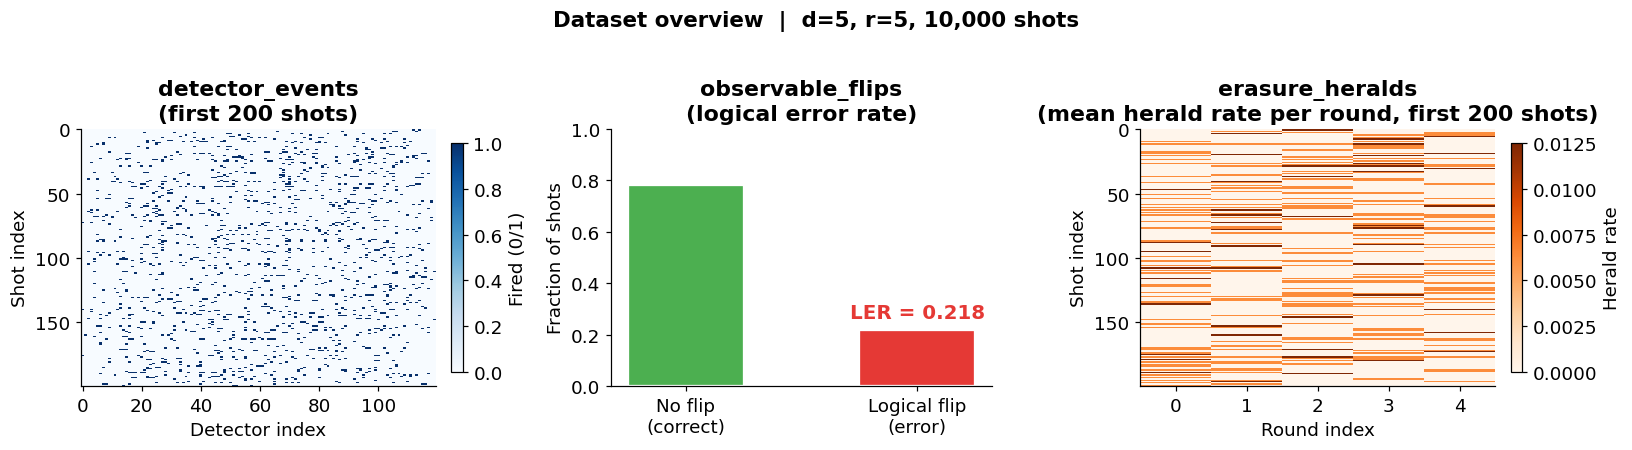

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- detector events heatmap (first 200 shots) ---
ax = axes[0]
im = ax.imshow(
    det_events[:200],
    aspect="auto",
    cmap="Blues",
    interpolation="nearest",
    vmin=0, vmax=1,
)
ax.set_title("detector_events\n(first 200 shots)", fontweight="bold")
ax.set_xlabel("Detector index")
ax.set_ylabel("Shot index")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Fired (0/1)")

# --- observable flips histogram ---
ax = axes[1]
raw_ler = obs_flips.mean()
ax.bar(["No flip\n(correct)", "Logical flip\n(error)"],
       [1 - raw_ler, raw_ler],
       color=["#4caf50", "#e53935"],
       edgecolor="white", linewidth=1.5, width=0.5)
ax.set_title("observable_flips\n(logical error rate)", fontweight="bold")
ax.set_ylabel("Fraction of shots")
ax.set_ylim(0, 1)
ax.text(1, raw_ler + 0.03, f"LER = {raw_ler:.3f}",
        ha="center", va="bottom", fontsize=13, color="#e53935", fontweight="bold")

# --- erasure heralds heatmap (first 200 shots, averaged over gates/qubits) ---
ax = axes[2]
# shape: (shots, rounds, gates, 2) → mean over gates and qubit dim → (shots, rounds)
herald_per_round = era_heralds[:200].mean(axis=(2, 3))
im2 = ax.imshow(
    herald_per_round,
    aspect="auto",
    cmap="Oranges",
    interpolation="nearest",
)
ax.set_title("erasure_heralds\n(mean herald rate per round, first 200 shots)",
             fontweight="bold")
ax.set_xlabel("Round index")
ax.set_ylabel("Shot index")
plt.colorbar(im2, ax=ax, fraction=0.03, pad=0.04, label="Herald rate")

fig.suptitle(
    f"Dataset overview  |  d={DEMO_D}, r={DEMO_R}, {N_SHOTS:,} shots",
    fontsize=14, fontweight="bold", y=1.02,
)
fig.tight_layout()
plt.show()

## 2. What a single shot looks like

Each shot is a row of bits. We can unfold those bits back onto the
space-time grid of the surface code.

### 2a. Surface code layout

Stim embeds qubit coordinates in the circuit. We extract them to
draw the physical layout.

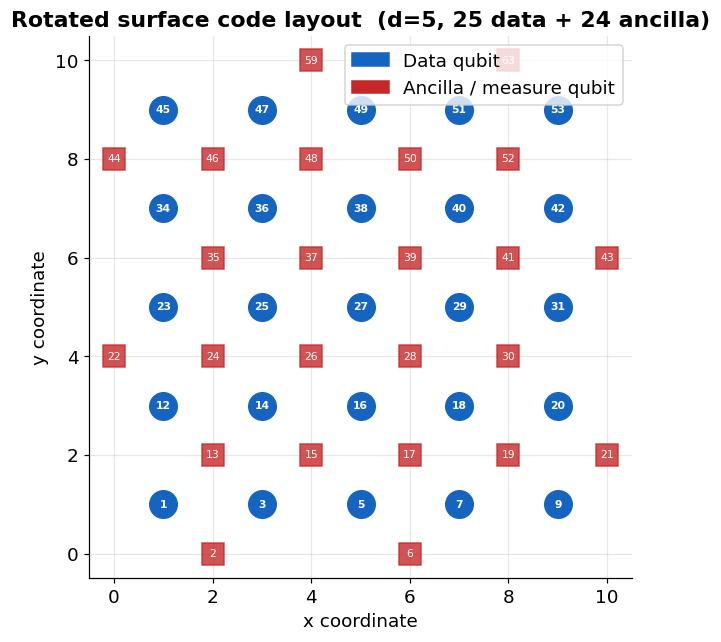

Data qubits   : [1, 3, 5, 7, 9, 12, 14, 16, 18, 20, 23, 25, 27, 29, 31, 34, 36, 38, 40, 42, 45, 47, 49, 51, 53]
Ancilla qubits: [2, 6, 13, 15, 17, 19, 21, 22, 24, 26, 28, 30, 35, 37, 39, 41, 43, 44, 46, 48, 50, 52, 59, 63]


In [ ]:
def get_qubit_coords(circuit):
    """Return dict qubit_index -> (x, y) from QUBIT_COORDS annotations."""
    coords = {}
    for inst in circuit.flattened():
        if inst.name == "QUBIT_COORDS":
            args = inst.gate_args_copy()
            for t in inst.targets_copy():
                coords[t.value] = (args[0], args[1])
    return coords


def get_ancilla_qubit_indices(circuit):
    """Return the set of ancilla qubit indices.

    Stim's surface_code generator uses integer coordinates for every qubit,
    so we cannot distinguish data from ancilla by coordinate parity.
    Instead we use the instruction type: ancilla qubits appear in MR
    (measure-and-reset) instructions that repeat every round, whereas data
    qubits are only measured once at the very end with a plain M.
    """
    ancilla = set()
    for inst in circuit.flattened():
        if inst.name == "MR":
            for t in inst.targets_copy():
                if t.is_qubit_target:
                    ancilla.add(t.value)
    return ancilla


qubit_coords = get_qubit_coords(circuit)
ancilla_set  = get_ancilla_qubit_indices(circuit)

data_qubits    = {q: xy for q, xy in qubit_coords.items() if q not in ancilla_set}
ancilla_qubits = {q: xy for q, xy in qubit_coords.items() if q in ancilla_set}

fig, ax = plt.subplots(figsize=(6, 6))

for q, (x, y) in data_qubits.items():
    ax.plot(x, y, "o", ms=18, color="#1565c0", zorder=3)
    ax.text(x, y, str(q), ha="center", va="center",
            color="white", fontsize=7, fontweight="bold", zorder=4)

for q, (x, y) in ancilla_qubits.items():
    ax.plot(x, y, "s", ms=14, color="#c62828", zorder=3, alpha=0.8)
    ax.text(x, y, str(q), ha="center", va="center",
            color="white", fontsize=7, zorder=4)

legend_handles = [
    mpatches.Patch(color="#1565c0", label="Data qubit"),
    mpatches.Patch(color="#c62828", label="Ancilla / measure qubit"),
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set_aspect("equal")
ax.set_title(f"Rotated surface code layout  (d={DEMO_D}, "
             f"{len(data_qubits)} data + {len(ancilla_qubits)} ancilla)",
             fontweight="bold")
ax.set_xlabel("x coordinate")
ax.set_ylabel("y coordinate")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Data qubits   : {sorted(data_qubits.keys())}")
print(f"Ancilla qubits: {sorted(ancilla_qubits.keys())}")

### 2b. Individual shot syndrome patterns

Detectors are ordered: $r$ rounds × (ancilla qubits per round).
We reshape a shot's detector vector into a 2-D grid
(space × time) to see error chains propagating across rounds.

Detectors: 120 total = 5 rounds × 24 ancilla


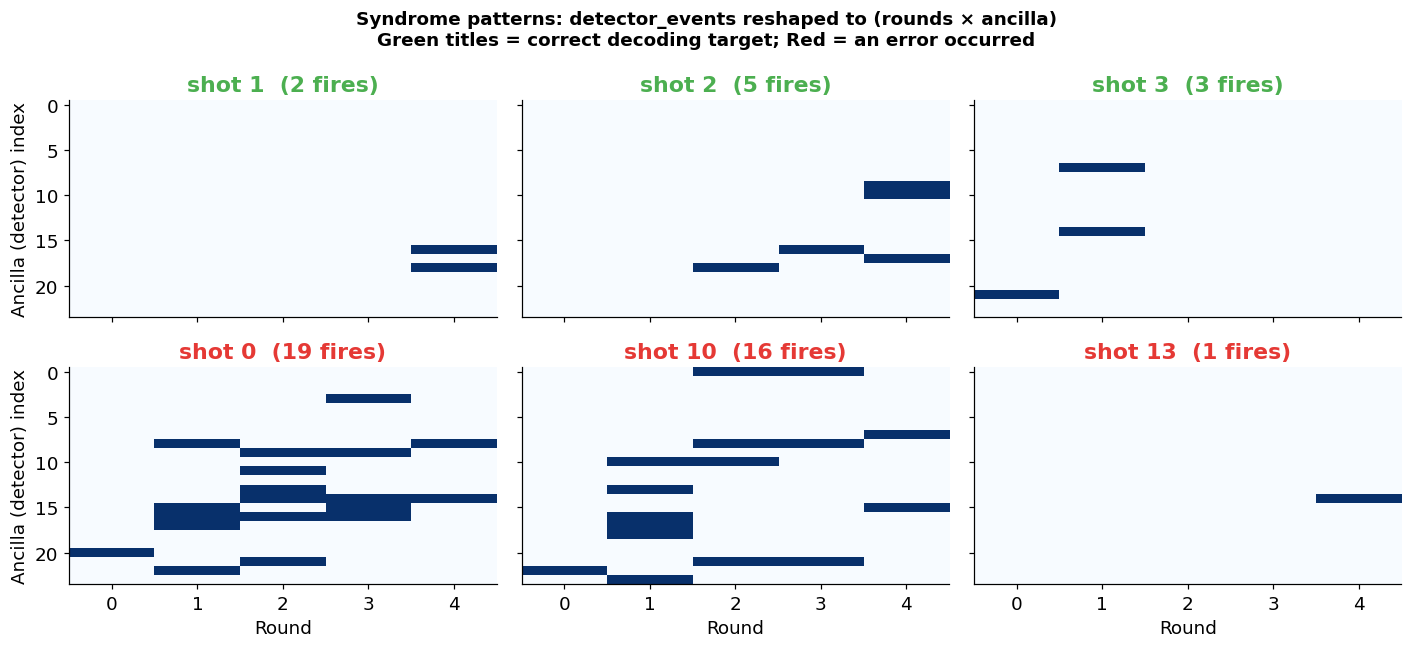

In [ ]:
n_ancilla = circuit.num_qubits - len(data_qubits)
n_det_per_round = N_DET // N_ROUNDS  # detectors per round

print(f"Detectors: {N_DET} total = {N_ROUNDS} rounds × {n_det_per_round} ancilla")

# Pick 6 shots to display: 3 with no logical flip, 3 with one.
no_flip_idx  = np.where(obs_flips[:, 0] == 0)[0][:3]
yes_flip_idx = np.where(obs_flips[:, 0] == 1)[0][:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 6),
                          sharex=True, sharey=True)

for row, (idxs, label, color) in enumerate([
    (no_flip_idx,  "No logical flip (correct)",  "#4caf50"),
    (yes_flip_idx, "Logical flip (error)",        "#e53935"),
]):
    for col, shot_i in enumerate(idxs):
        ax = axes[row, col]
        grid = det_events[shot_i].reshape(N_ROUNDS, n_det_per_round)
        ax.imshow(grid.T, aspect="auto", cmap="Blues",
                  vmin=0, vmax=1, interpolation="nearest")
        n_fires = det_events[shot_i].sum()
        ax.set_title(f"shot {shot_i}  ({n_fires} fires)",
                     color=color, fontweight="bold")
        if col == 0:
            ax.set_ylabel("Ancilla (detector) index")
        if row == 1:
            ax.set_xlabel("Round")

fig.suptitle(
    "Syndrome patterns: detector_events reshaped to (rounds × ancilla)\n"
    "Green titles = correct decoding target; Red = an error occurred",
    fontsize=12, fontweight="bold",
)
fig.tight_layout()
plt.show()

## 3. Detector statistics

**Detector firing rate** tells us how noisy each parity check is.
In a perfect circuit all rates would be 0. In our noise model they
vary slightly because of the spatial structure of the code.

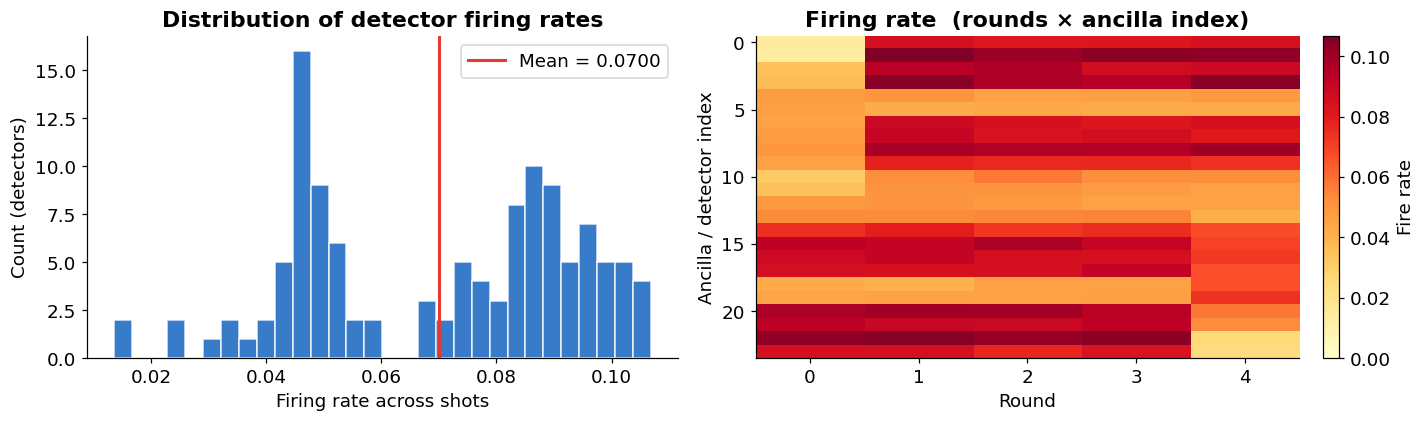

Min firing rate : 0.01350
Max firing rate : 0.10680
Mean firing rate: 0.07003


In [ ]:
fire_rates = det_events.mean(axis=0)   # (N_DET,)
rates_2d   = fire_rates.reshape(N_ROUNDS, n_det_per_round)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Overall distribution
ax = axes[0]
ax.hist(fire_rates, bins=30, color="#1565c0", edgecolor="white", alpha=0.85)
ax.axvline(fire_rates.mean(), color="#e53935", lw=2,
           label=f"Mean = {fire_rates.mean():.4f}")
ax.set_title("Distribution of detector firing rates", fontweight="bold")
ax.set_xlabel("Firing rate across shots")
ax.set_ylabel("Count (detectors)")
ax.legend()

# Space × time heatmap
ax = axes[1]
im = ax.imshow(rates_2d.T, aspect="auto", cmap="YlOrRd",
               interpolation="nearest", vmin=0)
ax.set_title("Firing rate  (rounds × ancilla index)", fontweight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("Ancilla / detector index")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label="Fire rate")

fig.tight_layout()
plt.show()

print(f"Min firing rate : {fire_rates.min():.5f}")
print(f"Max firing rate : {fire_rates.max():.5f}")
print(f"Mean firing rate: {fire_rates.mean():.5f}")

## 4. Detector correlations

Physically nearby detectors (in space or time) should be correlated:
a single error can make multiple parity checks fire together.
This correlation structure is what the neural decoder learns to exploit.

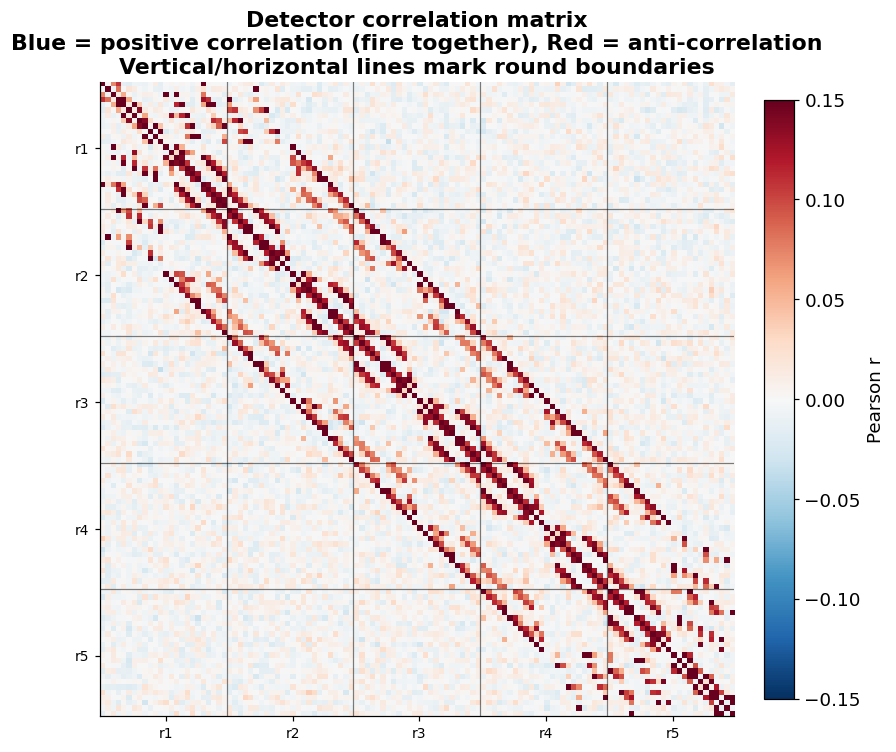

In [ ]:
# Pearson correlation matrix across detectors
# Center each detector first (subtract mean)
X = det_events.astype(np.float32) - fire_rates[np.newaxis, :]
std = X.std(axis=0, keepdims=True)
std[std == 0] = 1.0
X_norm = X / std
corr = (X_norm.T @ X_norm) / N_SHOTS   # (N_DET, N_DET)

fig, ax = plt.subplots(figsize=(8, 7))
cmap_div = plt.get_cmap("RdBu_r")
im = ax.imshow(corr, cmap=cmap_div, vmin=-0.15, vmax=0.15,
               interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label="Pearson r")

# Draw round boundaries
for r in range(1, N_ROUNDS):
    pos = r * n_det_per_round - 0.5
    ax.axhline(pos, color="black", lw=0.8, alpha=0.5)
    ax.axvline(pos, color="black", lw=0.8, alpha=0.5)

# Label round groups on x-axis
ticks = [r * n_det_per_round + n_det_per_round // 2 for r in range(N_ROUNDS)]
ax.set_xticks(ticks)
ax.set_xticklabels([f"r{r+1}" for r in range(N_ROUNDS)], fontsize=9)
ax.set_yticks(ticks)
ax.set_yticklabels([f"r{r+1}" for r in range(N_ROUNDS)], fontsize=9)

ax.set_title(
    "Detector correlation matrix\n"
    "Blue = positive correlation (fire together), Red = anti-correlation\n"
    "Vertical/horizontal lines mark round boundaries",
    fontweight="bold",
)
fig.tight_layout()
plt.show()

## 5. Erasure heralds in detail

The `erasure_heralds` array has shape
`(shots, rounds, gates_per_round, 2)`. The last axis indexes the
two qubits in each two-qubit gate. A `True` entry means that qubit
was detected as lost (atom loss) in that gate in that round.

In [ ]:
gates = two_qubit_gates_per_round(DEMO_D)
print(f"Two-qubit gates per round: {len(gates)}")
print(f"First few gate pairs (control, target): {gates[:5]}")
print(f"\nErasure herald array shape: {era_heralds.shape}")
print(f"  Axes: (shots, rounds, gates_per_round, [ctrl_qubit, tgt_qubit])")
print(f"\nOverall erasure rate: {era_heralds.mean():.5f}  (expected p_erasure={noise.p_erasure})")

Two-qubit gates per round: 80
First few gate pairs (control, target): [(2, 3), (24, 25), (46, 47), (15, 16), (37, 38)]

Erasure herald array shape: (10000, 5, 80, 2)
  Axes: (shots, rounds, gates_per_round, [ctrl_qubit, tgt_qubit])

Overall erasure rate: 0.00200  (expected p_erasure=0.002)


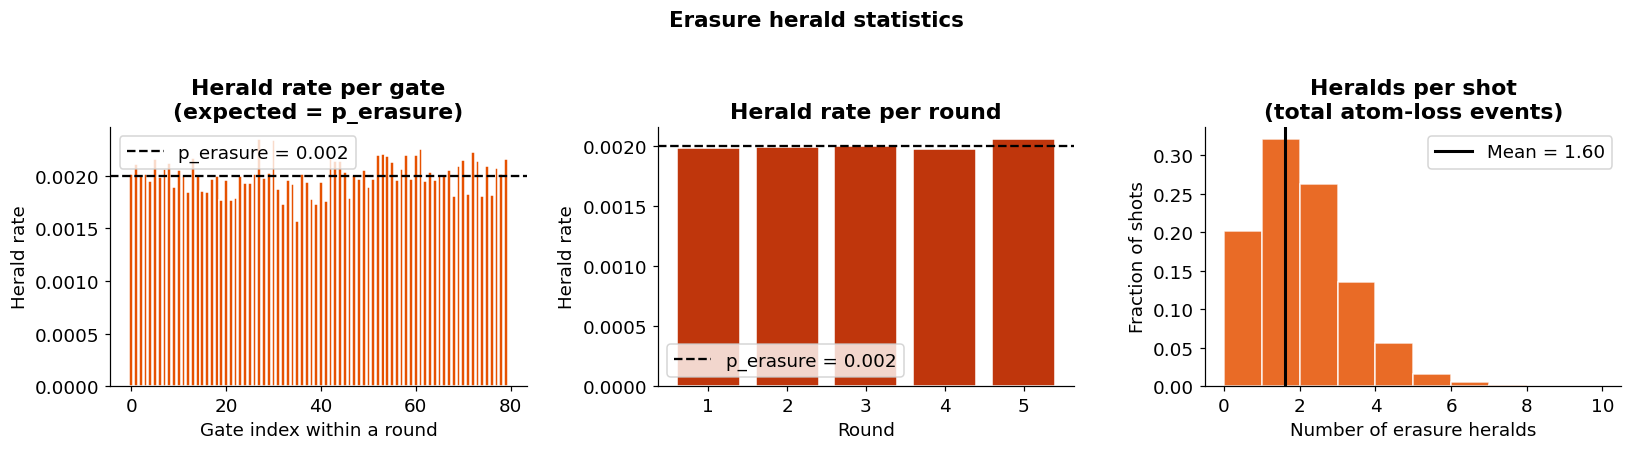

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Per-gate herald rate (averaged over shots, rounds, and qubit)
ax = axes[0]
gate_rates = era_heralds.mean(axis=(0, 1, 3))   # shape: (n_gates,)
ax.bar(range(len(gates)), gate_rates, color="#e65100", edgecolor="white")
ax.axhline(noise.p_erasure, color="black", lw=1.5, ls="--",
           label=f"p_erasure = {noise.p_erasure}")
ax.set_title("Herald rate per gate\n(expected = p_erasure)", fontweight="bold")
ax.set_xlabel("Gate index within a round")
ax.set_ylabel("Herald rate")
ax.legend()

# 2. Per-round herald rate
ax = axes[1]
round_rates = era_heralds.mean(axis=(0, 2, 3))   # shape: (rounds,)
ax.bar(range(1, N_ROUNDS + 1), round_rates, color="#bf360c", edgecolor="white")
ax.axhline(noise.p_erasure, color="black", lw=1.5, ls="--",
           label=f"p_erasure = {noise.p_erasure}")
ax.set_title("Herald rate per round", fontweight="bold")
ax.set_xlabel("Round")
ax.set_ylabel("Herald rate")
ax.legend()

# 3. Distribution: how many heralds per shot?
ax = axes[2]
heralds_per_shot = era_heralds.reshape(N_SHOTS, -1).sum(axis=1)
max_heralds = heralds_per_shot.max()
ax.hist(heralds_per_shot, bins=range(0, int(max_heralds) + 2),
        color="#e65100", edgecolor="white", alpha=0.85,
        density=True)
ax.set_title("Heralds per shot\n(total atom-loss events)", fontweight="bold")
ax.set_xlabel("Number of erasure heralds")
ax.set_ylabel("Fraction of shots")
mu = heralds_per_shot.mean()
ax.axvline(mu, color="black", lw=2, label=f"Mean = {mu:.2f}")
ax.legend()

fig.suptitle("Erasure herald statistics", fontsize=14,
             fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 6. Raw vs. decoded logical error rate

The **raw LER** is how often the logical qubit flip before any
decoding. The **PyMatching LER** is after a minimum-weight perfect
matching decoder. The neural decoder's job is to beat PyMatching.

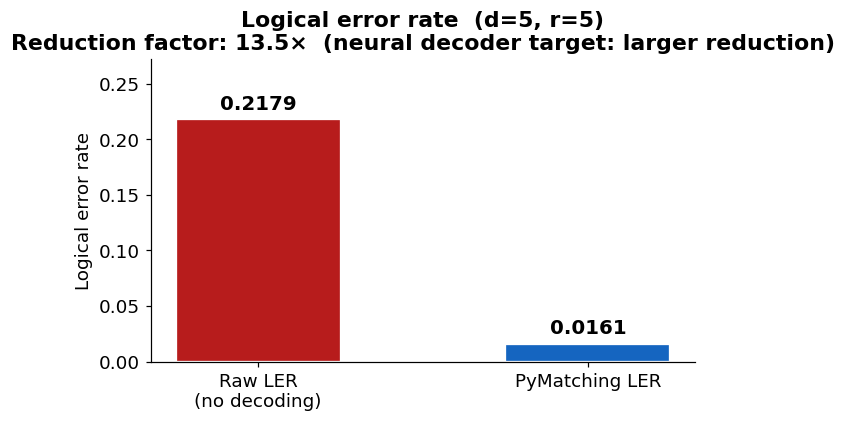

Raw LER       : 0.2179
PyMatching LER: 0.0161
Improvement   : 13.5×


In [ ]:
import pymatching

dem = circuit.detector_error_model(
    decompose_errors=True,
    approximate_disjoint_errors=True,
    ignore_decomposition_failures=True,
)
matcher = pymatching.Matching.from_detector_error_model(dem)
preds   = matcher.decode_batch(det_events)
mwpm_ler = float((preds != obs_flips).any(axis=1).mean())
raw_ler  = float(obs_flips.mean())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Raw LER\n(no decoding)", "PyMatching LER"],
    [raw_ler, mwpm_ler],
    color=["#b71c1c", "#1565c0"],
    edgecolor="white", linewidth=1.5, width=0.5,
)
for bar, val in zip(bars, [raw_ler, mwpm_ler]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.005, f"{val:.4f}",
            ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_title(
    f"Logical error rate  (d={DEMO_D}, r={DEMO_R})\n"
    f"Reduction factor: {raw_ler / mwpm_ler:.1f}×  "
    f"(neural decoder target: larger reduction)",
    fontweight="bold",
)
ax.set_ylabel("Logical error rate")
ax.set_ylim(0, max(raw_ler, mwpm_ler) * 1.25)
fig.tight_layout()
plt.show()

print(f"Raw LER       : {raw_ler:.4f}")
print(f"PyMatching LER: {mwpm_ler:.4f}")
print(f"Improvement   : {raw_ler / mwpm_ler:.1f}×")

## 7. What the decoder sees vs. what it must predict

A clean summary of the decoder's input/output interface.

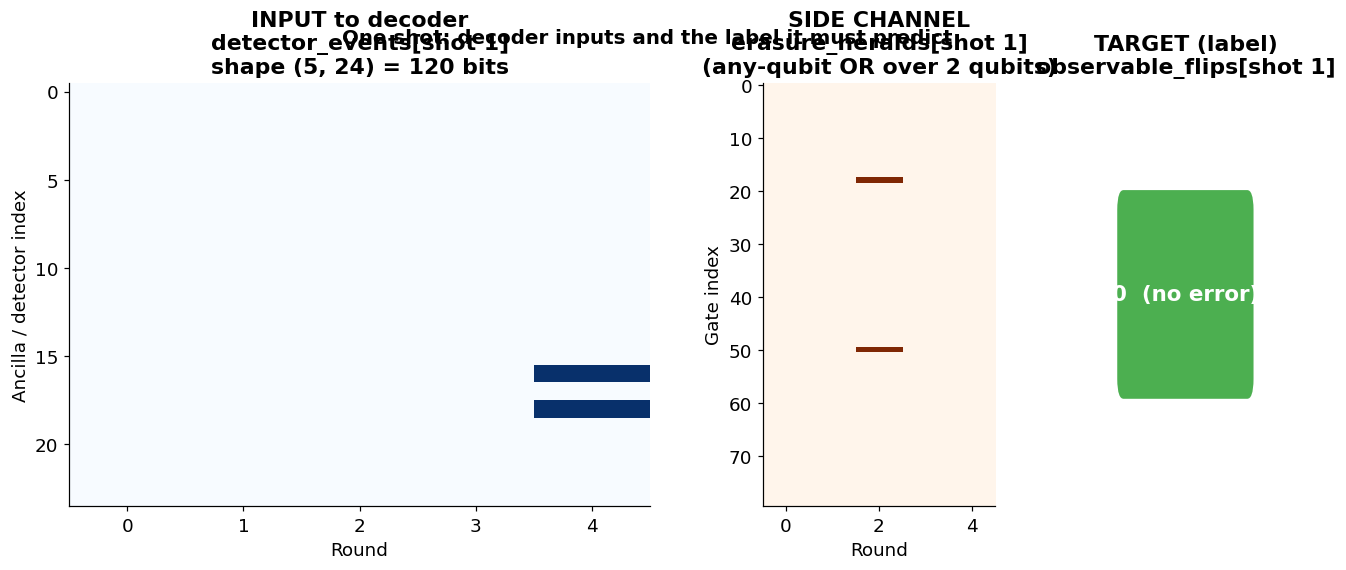

In [ ]:
shot_i = no_flip_idx[0]   # pick one shot to illustrate

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[3, 1.2, 0.8],
                        wspace=0.35)

# --- Input: detector events ---
ax0 = fig.add_subplot(gs[0])
grid = det_events[shot_i].reshape(N_ROUNDS, n_det_per_round)
ax0.imshow(grid.T, aspect="auto", cmap="Blues", vmin=0, vmax=1,
           interpolation="nearest")
ax0.set_title(
    f"INPUT to decoder\ndetector_events[shot {shot_i}]\n"
    f"shape ({N_ROUNDS}, {n_det_per_round}) = {N_DET} bits",
    fontweight="bold",
)
ax0.set_xlabel("Round")
ax0.set_ylabel("Ancilla / detector index")

# --- Side channel: erasure heralds ---
ax1 = fig.add_subplot(gs[1])
herald_grid = era_heralds[shot_i].any(axis=2)   # (rounds, gates) any qubit
ax1.imshow(herald_grid.T, aspect="auto", cmap="Oranges", vmin=0, vmax=1,
           interpolation="nearest")
ax1.set_title(
    f"SIDE CHANNEL\nerasure_heralds[shot {shot_i}]\n"
    f"(any-qubit OR over 2 qubits)",
    fontweight="bold",
)
ax1.set_xlabel("Round")
ax1.set_ylabel("Gate index")

# --- Output: observable flip ---
ax2 = fig.add_subplot(gs[2])
flip_val = int(obs_flips[shot_i, 0])
color = "#4caf50" if flip_val == 0 else "#e53935"
label = "0  (no error)" if flip_val == 0 else "1  (error!)"
ax2.add_patch(mpatches.FancyBboxPatch(
    (0.1, 0.3), 0.8, 0.4,
    boxstyle="round,pad=0.05",
    facecolor=color, edgecolor="white", linewidth=2,
))
ax2.text(0.5, 0.5, label, ha="center", va="center",
         color="white", fontsize=14, fontweight="bold", transform=ax2.transAxes)
ax2.set_title(
    f"TARGET (label)\nobservable_flips[shot {shot_i}]",
    fontweight="bold",
)
ax2.axis("off")

fig.suptitle(
    "One shot: decoder inputs and the label it must predict",
    fontsize=13, fontweight="bold",
)
plt.show()

## 8. Dataset files on disk

One `.npz` + one `.json` per configuration.

In [ ]:
npz_files = sorted(DATA_DIR.glob("*.npz"))
if not npz_files:
    print("No .npz files found in data/ — run the generation notebook first.")
else:
    print(f"{'File':<30} {'Shots':>8} {'Det':>6} {'Raw LER':>9} {'Size (MB)':>10}")
    print("-" * 66)
    for f in npz_files:
        d = np.load(f)
        raw_ler_f = d["observable_flips"].mean()
        shots_f   = d["detector_events"].shape[0]
        det_f     = d["detector_events"].shape[1]
        size_mb   = f.stat().st_size / 1e6
        print(f"{f.name:<30} {shots_f:>8,} {det_f:>6} {raw_ler_f:>9.4f} {size_mb:>10.2f}")
        d.close()

print("\n--- Metadata for current demo file ---")
if meta:
    for k, v in meta.items():
        if k != "noise":
            print(f"  {k}: {v}")
    print("  noise:")
    for k, v in meta.get("noise", asdict(noise)).items():
        print(f"    {k}: {v}")

File                              Shots    Det   Raw LER  Size (MB)
------------------------------------------------------------------
d5_r5_train.npz                  10,000    120    0.2179       0.14

--- Metadata for current demo file ---
  distance: 5
  rounds: 5
  noise:
    p_depol1: 0.001
    p_depol2: 0.005
    p_meas: 0.005
    p_reset: 0.001
    p_correlated_zz: 0.001
    p_erasure: 0.002
    erasure_depol_strength: 0.75


## Summary

| Aspect | Value / observation |
|--------|--------------------|
| Code | Rotated surface code, memory-Z experiment |
| Noise | Pauli-twirled circuit-level + correlated ZZ + erasure |
| Input to decoder | `detector_events` (syndrome bits) + optionally `erasure_heralds` |
| Label | `observable_flips` — 1 = logical error occurred |
| Baseline decoder | PyMatching (MWPM) — neural decoder must beat this |
| Key limitation | Erasure heralds are statistically independent of Pauli errors (approximation) |

